# GRAPH CONVOLUTIONAL NEURAL NETWORK - FRAME VALIDATION

## PARAMETER CONFIGURATION

In [139]:
batch_size = 8

data_files = [
    # FP11
    {"name": "FP11", "label": [0], "topology_filename": "../FP11_monomer/SYSTEMns.prmtop", "coordinates_filename": "../FP11_monomer/PRODUCTION_0/TRAJ-150ns.nc"},
    {"name": "FP11", "label": [0], "topology_filename": "../FP11_monomer/SYSTEMns.prmtop", "coordinates_filename": "../FP11_monomer/PRODUCTION_1/TRAJ-150ns.nc"},
    {"name": "FP11", "label": [0], "topology_filename": "../FP11_monomer/SYSTEMns.prmtop", "coordinates_filename": "../FP11_monomer/PRODUCTION_2/TRAJ-150ns.nc"},
    # FP12
    {"name": "FP12", "label": [1], "topology_filename": "../FP12-TLR4-MDago_monomer/SYSTEMns.prmtop", "coordinates_filename": "../FP12-TLR4-MDago_monomer/PRODUCTION_0/TRAJ-150ns.nc"},
    {"name": "FP12", "label": [1], "topology_filename": "../FP12-TLR4-MDago_monomer/SYSTEMns.prmtop", "coordinates_filename": "../FP12-TLR4-MDago_monomer/PRODUCTION_1/TRAJ-150ns.nc"},
    {"name": "FP12", "label": [1], "topology_filename": "../FP12-TLR4-MDago_monomer/SYSTEMns.prmtop", "coordinates_filename": "../FP12-TLR4-MDago_monomer/PRODUCTION_2/TRAJ-150ns.nc"},
    #FP18
    {"name": "FP18", "label": [0], "topology_filename": "../FP18_antagonistbox/SYSTEMns.prmtop", "coordinates_filename": "../FP18_antagonistbox/PRODUCTION_0/TRAJ-150ns.nc"},
    {"name": "FP18", "label": [0], "topology_filename": "../FP18_antagonistbox/SYSTEMns.prmtop", "coordinates_filename": "../FP18_antagonistbox/PRODUCTION_1/TRAJ-150ns.nc"},
    {"name": "FP18", "label": [0], "topology_filename": "../FP18_antagonistbox/SYSTEMns.prmtop", "coordinates_filename": "../FP18_antagonistbox/PRODUCTION_2/TRAJ-150ns.nc"},
    #FP7
    {"name": "FP7", "label": [1], "topology_filename": "../FP7/SYSTEMns.prmtop", "coordinates_filename": "../FP7/PRODUCTION_0/TRAJ-150ns.nc"},
    {"name": "FP7", "label": [1], "topology_filename": "../FP7/SYSTEMns.prmtop", "coordinates_filename": "../FP7/PRODUCTION_1/TRAJ-150ns.nc"},
    {"name": "FP7", "label": [1], "topology_filename": "../FP7/SYSTEMns.prmtop", "coordinates_filename": "../FP7/PRODUCTION_2/TRAJ-150ns.nc"}
]

epochs = 25
lr = 0.0001
test_size = 0.20
random_state = 42

In [140]:
data_files

[{'name': 'FP11',
  'label': [0],
  'topology_filename': '../FP11_monomer/SYSTEMns.prmtop',
  'coordinates_filename': '../FP11_monomer/PRODUCTION_0/TRAJ-150ns.nc'},
 {'name': 'FP11',
  'label': [0],
  'topology_filename': '../FP11_monomer/SYSTEMns.prmtop',
  'coordinates_filename': '../FP11_monomer/PRODUCTION_1/TRAJ-150ns.nc'},
 {'name': 'FP11',
  'label': [0],
  'topology_filename': '../FP11_monomer/SYSTEMns.prmtop',
  'coordinates_filename': '../FP11_monomer/PRODUCTION_2/TRAJ-150ns.nc'},
 {'name': 'FP12',
  'label': [1],
  'topology_filename': '../FP12-TLR4-MDago_monomer/SYSTEMns.prmtop',
  'coordinates_filename': '../FP12-TLR4-MDago_monomer/PRODUCTION_0/TRAJ-150ns.nc'},
 {'name': 'FP12',
  'label': [1],
  'topology_filename': '../FP12-TLR4-MDago_monomer/SYSTEMns.prmtop',
  'coordinates_filename': '../FP12-TLR4-MDago_monomer/PRODUCTION_1/TRAJ-150ns.nc'},
 {'name': 'FP12',
  'label': [1],
  'topology_filename': '../FP12-TLR4-MDago_monomer/SYSTEMns.prmtop',
  'coordinates_filename': '.

In [141]:
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

from torch.nn import Embedding, CrossEntropyLoss, Linear, ReLU
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, AttentionalAggregation
from torch_geometric.nn import radius_graph
from torch_geometric.utils import scatter
from sklearn.model_selection import train_test_split, KFold

import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tqdm
import json

In [142]:
torch.cuda.is_available()

True

## DATA LOAD

In [143]:
# u = mda.Universe("../data/md-2025-03-11/FP11ns.prmtop", "../data/md-2025-03-11/FP11-150ns.nc")
# residue_index = dict((key, id) for id, key in enumerate(np.unique(u.select_atoms('name CA').resnames).tolist()))
# atom_type_index = dict((key, id) for id, key in enumerate(np.unique(u.select_atoms('protein').atoms.types.tolist())))

with open('atom-list.json') as f: 
    atom_type_index = json.load(f)
with open('residue-list.json') as f: 
    residue_index = json.load(f)

In [144]:
def trajectory_to_data(u, selection_string, residue_index, atom_type_index, label):
    for fr in u.trajectory:
        x = torch.from_numpy(u.select_atoms(selection_string).positions)
        residues = list(map(lambda x: residue_index[x], u.select_atoms(selection_string).resnames))
        atom_types = list(map(lambda x: atom_type_index[x], u.select_atoms(selection_string).atoms.types.tolist()))
        d = Data(pos=x, res=torch.tensor(residues, dtype=torch.long), types=torch.tensor(atom_types, dtype=torch.long), label=torch.tensor(label, dtype=torch.long))
        yield d

### Frame Data Splitting

In [145]:
compound_groups = {
    "group1": {
        "selection_string": "resid 613:754 and name CA N C O",
        "compounds": ["FP11", "FP12"]
    },
    "group2": {
        "selection_string": "resid 9:150 and name CA N C O",
        "compounds": ["FP18"]
    },
    "group3": {
        "selection_string": "resid 612:753 and name CA N C O",
        "compounds": ["FP7"]
    }
}

In [146]:
for group in compound_groups.values():
    print(group["compounds"])

['FP11', 'FP12']
['FP18']
['FP7']


In [147]:
for group in compound_groups.values():
    print(group["selection_string"])

resid 613:754 and name CA N C O
resid 9:150 and name CA N C O
resid 612:753 and name CA N C O


In [148]:
trj = []

for group in compound_groups.values():
    selection_string = group["selection_string"]
    for file in data_files:
        if file["name"] in group["compounds"]:
            u = mda.Universe(file['topology_filename'], file['coordinates_filename'])
            trj += list(trajectory_to_data(u, selection_string, residue_index, atom_type_index, file['label']))
            print(file['coordinates_filename']) # to check all files are read correctly
            print(len(u.trajectory)) # to check there are 1500 frames per file

print("")
print(len(trj))

../FP11_monomer/PRODUCTION_0/TRAJ-150ns.nc
1500
../FP11_monomer/PRODUCTION_1/TRAJ-150ns.nc
1500
../FP11_monomer/PRODUCTION_2/TRAJ-150ns.nc
1500
../FP12-TLR4-MDago_monomer/PRODUCTION_0/TRAJ-150ns.nc
1500
../FP12-TLR4-MDago_monomer/PRODUCTION_1/TRAJ-150ns.nc
1500
../FP12-TLR4-MDago_monomer/PRODUCTION_2/TRAJ-150ns.nc
1500
../FP18_antagonistbox/PRODUCTION_0/TRAJ-150ns.nc
1500
../FP18_antagonistbox/PRODUCTION_1/TRAJ-150ns.nc
1500
../FP18_antagonistbox/PRODUCTION_2/TRAJ-150ns.nc
1500
../FP7/PRODUCTION_0/TRAJ-150ns.nc
1500
../FP7/PRODUCTION_1/TRAJ-150ns.nc
1500
../FP7/PRODUCTION_2/TRAJ-150ns.nc
1500

18000


In [149]:
trj[:5]

[Data(pos=[568, 3], res=[568], types=[568], label=[1]),
 Data(pos=[568, 3], res=[568], types=[568], label=[1]),
 Data(pos=[568, 3], res=[568], types=[568], label=[1]),
 Data(pos=[568, 3], res=[568], types=[568], label=[1]),
 Data(pos=[568, 3], res=[568], types=[568], label=[1])]

In [150]:
train_trj, test_trj = train_test_split(trj, test_size=test_size, random_state=random_state)

In [151]:
len(train_trj)

14400

In [152]:
len(test_trj)

3600

#### First 750 frames for training and last 750 frames for test

In [22]:
# First 750 frames for training and last 750 frames for test
frames_per_simulation = 1500
chunk_size = 750

train_trj = []
test_trj = []

# 
for i in range(0, len(trj), frames_per_simulation):
    simulation_frames = trj[i:i + frames_per_simulation] # Extract the current simulation frames
    train_trj.extend(simulation_frames[:chunk_size]) # First 750 frames to train
    test_trj.extend(simulation_frames[chunk_size:]) # Last 750 frames to test

In [23]:
len(train_trj)

9000

In [24]:
len(test_trj)

9000

#### Split simulation data every 100 frames

In [111]:
# Split every 100 frames
frames_per_simulation = 1500
chunk_size = 100

train_trj = []
test_trj = []

for i in range(0, len(trj), frames_per_simulation):
    simulation_frames = trj[i:i + frames_per_simulation] # Extract the current simulation frames
    for j in range(0, frames_per_simulation, chunk_size): 
        chunk = simulation_frames[j:j + chunk_size] # Iterate each 100 frames
        if(j // chunk_size) % 2 == 0: # If index of chunk is even (0, 2, 4, etc) go to train
            train_trj.extend(chunk)
        else:
            test_trj.extend(chunk) # If odd (1, 3, 5, etc) go to test

In [112]:
len(train_trj)

9600

In [113]:
len(test_trj)

8400

## GRAPH MANIPULATION

In [55]:
import networkx as nx
train_trj[20]
edges = radius_graph(train_trj[20].pos, r=1.5)
G = nx.Graph()
G.add_edges_from(edges.T.tolist())

In [56]:
len(list(nx.connected_components(G)))

127

## MODEL

In [153]:
class GCN(torch.nn.Module):
    def __init__(self, radius):
        super().__init__()
        self.radius = radius
        self.embed_res = Embedding(num_embeddings=24, embedding_dim=128)
        self.embed_type = Embedding(num_embeddings=33, embedding_dim=128)
        # RESDIUE TYPE BRANCH
        self.conv1_res = GCNConv(128, 64)
        self.relu1_res = ReLU()
        self.conv2_res = GCNConv(64, 32)
        self.relu2_res = ReLU()
        self.conv3_res = GCNConv(32, 16)
        # ATOM TYPE BRANCH
        self.conv1_type = GCNConv(128, 64)
        self.relu1_type = ReLU()
        self.conv2_type = GCNConv(64, 32)
        self.relu2_type = ReLU()
        self.conv3_type = GCNConv(32, 16)
        # ATTENTION MECHANISM IN POOLING LAYER
        self.pool_res = AttentionalAggregation(gate_nn=torch.nn.Sequential(Linear(16,1),ReLU(),Linear(1,1)))
        self.pool_type = AttentionalAggregation(gate_nn=torch.nn.Sequential(Linear(16,1),ReLU(),Linear(1,1)))
        # LINEAR LAYER
        self.linear1 = Linear(32, 2)

    def forward(self, data):
        pos, res, type, batch = data.pos, data.res, data.types, data.batch
        edge_index = radius_graph(pos, r=self.radius, batch=batch)
        # FORWARD PASS OF RESIDUES TYPES
        z_res = self.embed_res(res)
        z_res = self.conv1_res(z_res, edge_index)
        z_res = self.relu1_res(z_res)
        z_res = self.conv2_res(z_res, edge_index)
        z_res = self.relu2_res(z_res)
        z_res = self.conv3_res(z_res, edge_index)
        # FORWARD PASS OF ATOMS TYPES
        z_type = self.embed_type(type)
        z_type = self.conv1_type(z_type, edge_index)
        z_type = self.relu1_type(z_type)
        z_type = self.conv2_type(z_type, edge_index)
        z_type = self.relu2_type(z_type)
        z_type = self.conv3_type(z_type, edge_index)
        #
        #z_res = scatter(z_res, data.batch, dim=0, reduce='mean')
        #z_type = scatter(z_type, data.batch, dim=0, reduce='mean')
        # FORWARD PASS POOLING AND LINEAR LAYER
        z_res = self.pool_res(z_res, data.batch)
        z_type = self.pool_type(z_type, data.batch)
        z = torch.cat([z_res, z_type], dim=1)
        z = self.linear1(z)
        # z = torch.randn_like(z)
        #z = F.softmax(z, dim=1) #CrossEntropyLoss already does softmax at the end
        return z

    def embed(self, data):
        pos, res, type, batch = data.pos, data.res, data.types, data.batch
        edge_index = radius_graph(pos, r=self.radius, batch=batch)
        # FORWARD PASS OF RESIDUES TYPES
        z_res = self.embed_res(res)
        z_res = self.conv1_res(z_res, edge_index)
        z_res = self.relu1_res(z_res)
        z_res = self.conv2_res(z_res, edge_index)
        z_res = self.relu2_res(z_res)
        z_res = self.conv3_res(z_res, edge_index)
        # FORWARD PASS OF ATOMS TYPES
        z_type = self.embed_type(type)
        z_type = self.conv1_type(z_type, edge_index)
        z_type = self.relu1_type(z_type)
        z_type = self.conv2_type(z_type, edge_index)
        z_type = self.relu2_type(z_type)
        z_type = self.conv3_type(z_type, edge_index)
        #
        z_res = scatter(z_res, data.batch, dim=0, reduce='mean')
        z_type = scatter(z_type, data.batch, dim=0, reduce='mean')
        # FORWARD PASS POOLING AND LINEAR LAYER
        # z_res = self.pool_res(z_res, data.batch)
        # z_type = self.pool_type(z_type, data.batch)
        z = torch.cat([z_res, z_type], dim=1)
        return z

## VALIDATION

In [155]:
gcn = GCN(radius=5.0).to(torch.device("cuda:0"))
loss = CrossEntropyLoss()
optimizer = torch.optim.Adam(gcn.parameters(), lr=1e-4, weight_decay=5e-4)
train_loader = DataLoader(train_trj, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_trj, batch_size=batch_size, shuffle=True)
history = []
for i in tqdm.tqdm(range(epochs)):
    statistics = dict()
    statistics['training_loss'] = 0.0
    gcn.train()
    for d in train_loader:
        d = d.to(torch.device("cuda:0"))
        optimizer.zero_grad()
        z = gcn(d)
        l = loss(z, d.label)
        l.backward()
        optimizer.step()
        statistics['training_loss'] += l.item()
        #print("Label shape: ", d.label.shape)
    statistics['training_loss'] /= len(train_loader)
    gcn.eval()
    with torch.no_grad():
        statistics['test_accuracy'] = 0.0
        statistics['test_loss'] = 0.0
        for d in test_loader:
            d = d.to(torch.device("cuda:0"))
            z = gcn(d)
            l = loss(z, d.label)
            a = ((z.argmax(1) == d.label).sum())
            statistics['test_accuracy'] += a.item()
            statistics['test_loss'] += l.item()
            #print("Label ", d.label)
    statistics['test_accuracy'] /= len(test_trj)
    statistics['test_loss'] /= ((len(test_trj) // batch_size) + 1)
    print(statistics)
    # print(f"Epoch {i+1:2d} | Accuracy {statistics['test_accuracy']:.4f}")
    history.append(statistics)

  4%|███▍                                                                                 | 1/25 [00:45<18:08, 45.37s/it]

{'training_loss': 0.6933925762441423, 'test_accuracy': 0.5011111111111111, 'test_loss': 0.692216030774254}


  8%|██████▊                                                                              | 2/25 [01:30<17:24, 45.43s/it]

{'training_loss': 0.6934283143944211, 'test_accuracy': 0.5011111111111111, 'test_loss': 0.690662491347996}


 12%|██████████▏                                                                          | 3/25 [02:18<17:01, 46.44s/it]

...

{'training_loss': 0.4552230508211586, 'test_accuracy': 0.8061111111111111, 'test_loss': 0.4476906378028662}


 96%|████████████████████████████████████████████████████████████████████████████████▋   | 24/25 [18:17<00:46, 46.28s/it]

{'training_loss': 0.44164643158515293, 'test_accuracy': 0.8083333333333333, 'test_loss': 0.4390705071901799}


100%|████████████████████████████████████████████████████████████████████████████████████| 25/25 [19:02<00:00, 45.71s/it]

{'training_loss': 0.43078459520720774, 'test_accuracy': 0.8091666666666667, 'test_loss': 0.4376743243895719}


In [156]:
pd.DataFrame.from_records(history)

,training_loss,test_accuracy,test_loss
0,0.693393,0.501111,0.692216
1,0.693428,0.501111,0.690662
2,0.693011,0.498889,0.690550
3,0.692816,0.501389,0.690489
4,0.692597,0.501111,0.690549
5,0.692481,0.501111,0.692473
6,0.692346,0.501111,0.691863
7,0.692265,0.498889,0.690294
8,0.691674,0.501111,0.689731
9,0.691235,0.635000,0.688970


### Why we get 0.0, 0.5 or 0.75

In [91]:
from sklearn.manifold import TSNE

In [92]:
train_loader = DataLoader(train_trj, batch_size=200, shuffle=True)
test_loader = DataLoader(test_trj, batch_size=200, shuffle=True)
with torch.no_grad():
    for d_train in train_loader:
        d_train = d_train.to(torch.device("cuda:0"))
        z_train = gcn.embed(d_train)
        break
    for d_test in test_loader:
        d_test = d_test.to(torch.device("cuda:0"))
        z_test = gcn.embed(d_test)
        break

In [93]:
z_train = z_train.detach().to(torch.device("cpu")).numpy()
z_test = z_test.detach().to(torch.device("cpu")).numpy()

In [94]:
label_train = d_train.label.detach().to(torch.device("cpu")).numpy()
label_test = d_test.label.detach().to(torch.device("cpu")).numpy()

In [95]:
z = np.concat([z_train, z_test])
d = np.concat([label_train, label_test])

In [96]:
u = TSNE(perplexity=30).fit_transform(z)

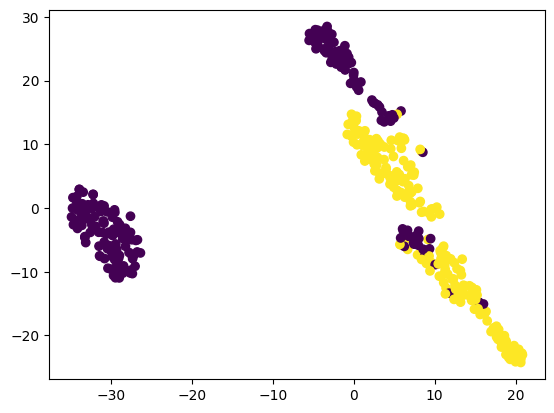

In [97]:
plt.scatter(u[:,0], u[:, 1], c=d)

In [34]:
class DummyNet(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.embed_res = Embedding(num_embeddings=24, embedding_dim=32)
        self.linear1 = Linear(32, 2)

    def forward(self, data):
        pos, res, type, batch = data.pos, data.res, data.types, data.batch
        z_res = self.embed_res(res)
        z_res = scatter(z_res, data.batch, dim=0, reduce='mean')
        print(z_res.shape)
        z = self.linear1(z_res)
        return z

In [39]:
dn = DummyNet().to(torch.device("cuda:0"))

dn(d)

torch.Size([21, 32])


tensor([[-0.0335, -0.0259],
        [-0.0335, -0.0259],
        [-0.1725,  0.0515],
        [-0.1725,  0.0515],
        [-0.1725,  0.0515],
        [-0.1725,  0.0515],
        [-0.1725,  0.0515],
        [-0.1725,  0.0515],
        [-0.0335, -0.0259],
        [-0.0335, -0.0259],
        [-0.0335, -0.0259],
        [-0.1725,  0.0515],
        [-0.1725,  0.0515],
        [-0.0335, -0.0259],
        [-0.0335, -0.0259],
        [-0.0335, -0.0259],
        [-0.1725,  0.0515],
        [-0.0335, -0.0259],
        [-0.1725,  0.0515],
        [-0.0335, -0.0259],
        [-0.0335, -0.0259]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [58]:
test_loader = DataLoader(train_trj, batch_size=123, shuffle=True)
# gcn = GCN(radius=5.0).to(torch.device("cuda:0"))
with torch.no_grad():
    statistics['test_accuracy'] = 0.0
    statistics['test_loss'] = 0.0
    for d in test_loader:
        d = d.to(torch.device("cuda:0"))
        z = gcn(d)
        l = loss(z, d.label)
        a = ((z.argmax(1) == d.label).sum())
        statistics['test_accuracy'] += a.item()
        statistics['test_loss'] += l.item()
        #print("Label ", d.label)
statistics['test_accuracy'] /= len(test_trj)
statistics['test_loss'] /= ((len(test_trj) // 123) + 1)
statistics
        

{'training_loss': 0.657049328327179,
 'test_accuracy': 0.8086666666666666,
 'test_loss': 0.64331780655964}

In [56]:
z.argmax(1)

tensor([1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1],
       device='cuda:0')

In [57]:
d.label

tensor([0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0],
       device='cuda:0')

In [ ]:
z.argmax(1)

In [55]:
((z.argmax(1) == d.label).sum())

tensor(4, device='cuda:0')

In [51]:
d.label

tensor([0, 1, 0, 1, 1, 1, 0, 1], device='cuda:0')

In [139]:
pd.DataFrame.from_records(history)

,training_loss,test_accuracy,test_loss
0,0.001143,0.505333,1.131206
1,0.000589,0.504333,1.242822
2,0.000350,0.504000,1.297873
3,0.000338,0.506222,1.366027
4,0.000216,0.507222,1.417657
5,0.000269,0.513778,1.592442
6,0.000168,0.511889,1.678473
7,0.000149,0.511667,1.568072
8,0.000106,0.503444,1.357244
9,0.000163,0.505333,1.362921


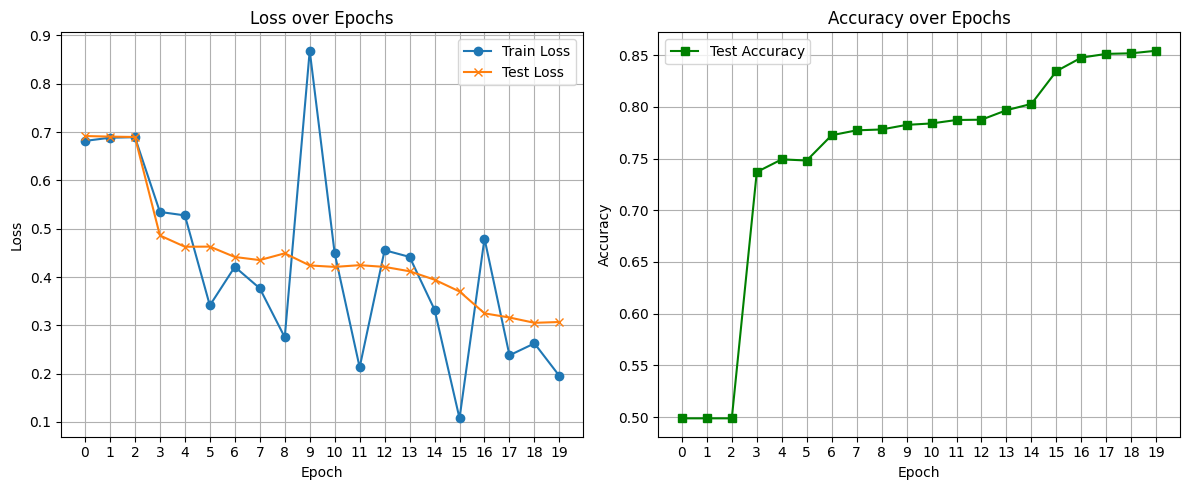

In [14]:
# Plotting the results
train_loss = [h['training_loss'] for h in history]
test_loss = [h['test_loss'] for h in history]
test_accuracy = [h['test_accuracy'] for h in history]
epochs_count = list(range(0, len(history)))
#epochs_count = list(range(0,20))
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_loss, label='Train Loss', marker='o')
plt.plot(test_loss, label='Test Loss', marker='x')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(epochs_count)
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(test_accuracy, label='Test Accuracy', marker='s', color='green')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(epochs_count)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [32]:
gcn

GCN(
  (embed_res): Embedding(24, 128)
  (embed_type): Embedding(33, 128)
  (conv1_res): GCNConv(128, 64)
  (relu1_res): ReLU()
  (conv2_res): GCNConv(64, 32)
  (relu2_res): ReLU()
  (conv3_res): GCNConv(32, 16)
  (conv1_type): GCNConv(128, 64)
  (relu1_type): ReLU()
  (conv2_type): GCNConv(64, 32)
  (relu2_type): ReLU()
  (conv3_type): GCNConv(32, 16)
  (pool_res): AttentionalAggregation(gate_nn=Sequential(
    (0): Linear(in_features=16, out_features=1, bias=True)
    (1): ReLU()
    (2): Linear(in_features=1, out_features=1, bias=True)
  ), nn=None)
  (pool_type): AttentionalAggregation(gate_nn=Sequential(
    (0): Linear(in_features=16, out_features=1, bias=True)
    (1): ReLU()
    (2): Linear(in_features=1, out_features=1, bias=True)
  ), nn=None)
  (linear1): Linear(in_features=32, out_features=2, bias=True)
)